# Full Dataset Gender Extraction

In [6]:
import pandas as pd
import spacy
import re
from tqdm import tqdm
from gender_guesser.detector import Detector

tqdm.pandas(desc="Processing Snippets")

print("Loading spaCy model...")
nlp = spacy.load("en_core_web_sm")

print("Loading Gender Guesser...")
detector = Detector(case_sensitive=False)

print("Loading data...")
df_all = pd.read_csv('../../data/snippets/total_snippets.csv')

metadata_df = pd.read_parquet('../../data/metadata_files/GP_opium_filtered_1850_1930.parquet')
authors_info_df = pd.read_csv('../../data/metadata_files/authors_info.csv')

df_all = df_all.merge(
    metadata_df[['Etext Number', 'Authors', 'LoCC', 'Published Year']],
    left_on='Book_ID',
    right_on='Etext Number',
    how='left'
)

df_all = df_all.merge(
    authors_info_df[['Authors', 'Author Gender']],
    on='Authors',
    how='left'
)
print(f'Total snippets loaded: {len(df_all)}')

Loading spaCy model...
Loading Gender Guesser...
Loading data...
Total snippets loaded: 5370


## NLP Pipeline

Define vocabs for keyword-matching later

In [7]:
MALE_VOCAB = {
    'he', 'him', 'his', 'man', 'boy', 'gentleman',
    'father', 'brother', 'husband', 'uncle',
    'son', 'master', 'sir', 'lord', 'clergyman',
    'mr', 'mister', 'colonel', 'major', 'captain'
}

FEMALE_VOCAB = {
    'she', 'her', 'hers', 'woman', 'girl', 'lady',
    'mother', 'sister', 'wife', 'aunt',
    'daughter', 'mistress', 'widow', 'governess', 
    'nurse', 'mrs', 'miss', 'madam', 'madame'
}

FIRST_PERSON = {
    'i', 'me', 'my', 'mine',
    'we', 'us', 'our', 'ours'
}

SPEECH_VERBS = {
    "say", "said", "reply", "replied",
    "ask", "asked", "remark", "remarked",
    "cry", "cried", "whisper", "whispered",
    "murmur", "murmured"
}

Define utils functions:

In [8]:
# Token role detection
def get_token_role(text):
    """
    Returns:
        ("FirstPerson", None)
        ("ThirdPerson", "Male")
        ("ThirdPerson", "Female")
        (None, None)
    """
    t = text.lower()

    if t in FIRST_PERSON:
        return ("FirstPerson", None)

    if t in MALE_VOCAB:
        return ("ThirdPerson", "Male")

    if t in FEMALE_VOCAB:
        return ("ThirdPerson", "Female")

    return (None, None)


# Context fallback
def get_contextual_scores(doc, kw_idx, window=30):
    scores = { "Male": 0.0, "Female": 0.0 }

    start = max(0, kw_idx - window)
    end = min(len(doc), kw_idx + window)

    for i in range(start, end):
        token = doc[i]
        role, gender = get_token_role(token.text)

        if role == "ThirdPerson":
            distance = abs(i - kw_idx)
            weight = max(0.1, 1 - (distance / window))
            scores[gender] += weight

    return scores

# Dialogue detection (for first-person resolution)
def keyword_in_dialogue(text, keyword):
    pattern = (
        r'["“][^"”]*'
        + re.escape(keyword.lower())
        + r'[^"”]*["”]'
    )

    return bool(re.search(pattern, text.lower()))

# Speaker resolution (1st person)
def resolve_dialogue_speaker(doc, kw_token):
    window_start = max(0, kw_token.i - 50)
    window_end = min(len(doc), kw_token.i + 50)

    nearby = doc[window_start:window_end]
    for token in nearby:
        if token.lemma_.lower() in SPEECH_VERBS:
            for child in token.children:
                # pronoun subjects
                role, gender = get_token_role(child.text)

                if role == "ThirdPerson":
                    return gender, child.text

                # named PERSON entities
                for ent in doc.ents:
                    if (ent.label_ == "PERSON" and ent.start <= child.i < ent.end):
                        first_name = ent.text.split()[0]
                        guess = detector.get_gender(first_name)
                        if "female" in guess:
                            return "Female", ent.text

                        elif "male" in guess:
                            return "Male", ent.text

    return "Unknown", "Anonymous"

# Character name resolution (1st person)
def resolve_character_name(doc, keyword_idx, target_gender):
    candidates = []
    for ent in doc.ents:
        if ent.label_ != "PERSON":
            continue
        first_name = ent.text.split()[0]
        guess = detector.get_gender(first_name)

        is_match = (
            (target_gender == "Female" and "female" in guess)
            or
            (target_gender == "Male" and "male" in guess)
            or
            (guess == "unknown")
        )

        if is_match:
            dist = abs(ent.start - keyword_idx)
            candidates.append((ent.text, dist))

    if candidates:
        return sorted(candidates, key=lambda x: x[1])[0][0]

    return "Anonymous"


# First-person narration
def resolve_first_person_narrator(row, scores):
    genres = row.get('Genres', [])
    author_gender = str(row.get('Author Gender', '')).lower()
    is_fiction = 'Fiction' in genres

    # non-fiction:
    # assume narrator ~= author
    if not is_fiction:
        if author_gender in ['male', 'female']:
            return author_gender.title()

        return "Unknown"

    # fiction:
    # weak contextual fallback
    if scores["Male"] > scores["Female"] * 1.5:
        return "Male"

    if scores["Female"] > scores["Male"] * 1.5:
        return "Female"

    if author_gender in ['male', 'female']:
        return author_gender.title()

    return "Unknown"

Main pipeline

In [9]:
def extract_opium_identity(row):
    text = str(row['Snippet'])
    keyword = str(row['Keyword']).lower()
    doc = nlp(text)

    # 1. Locate keyword token & FILTER PROPER NOUNS (e.g., Dr. Anodyne)
    kw_token = next((t for t in doc if t.lemma_.lower() == keyword), None)
    
    if not kw_token or kw_token.pos_ == "PROPN":
        return "Unknown (Proper Noun)", "Anonymous"

    final_gender = "Unknown"
    character_name = "Anonymous"

    # -----------------------------------------------------
    # STEP A: DEPENDENCY PARSING
    # -----------------------------------------------------
    head = kw_token
    while head.head != head and head.pos_ != "VERB":
        head = head.head

    detected_first_person = False
    
    # Look for Subjects and Objects (dobj, pobj, dative)
    target_deps = {"nsubj", "nsubjpass", "poss", "dobj", "pobj", "dative", "attr"}

    for child in head.children:
        if child.dep_ in target_deps:
            role, gender = get_token_role(child.text)
            
            if role == "FirstPerson":
                detected_first_person = True
                break
            elif role == "ThirdPerson":
                final_gender = gender
                # Try to see if this pronoun refers to a nearby name
                character_name = resolve_character_name(doc, child.i, gender)
                break
            
            # NEW: If it's a NAME (not in vocab), check gender immediately
            elif child.ent_type_ == "PERSON":
                first_name = child.text.split()[0]
                guess = detector.get_gender(first_name)
                if "female" in guess:
                    final_gender = "Female"
                    character_name = child.text
                    break
                elif "male" in guess:
                    final_gender = "Male"
                    character_name = child.text
                    break

    # -----------------------------------------------------
    # STEP B: FIRST-PERSON RESOLUTION (Narrator vs Dialogue)
    # -----------------------------------------------------
    if detected_first_person:
        if keyword_in_dialogue(text, keyword):
            final_gender, character_name = resolve_dialogue_speaker(doc, kw_token)
        else:
            scores = get_contextual_scores(doc, kw_token.i)
            final_gender = resolve_first_person_narrator(row, scores)

    # -----------------------------------------------------
    # STEP C: CONTEXTUAL FALLBACK
    # -----------------------------------------------------
    if final_gender == "Unknown":
        scores = get_contextual_scores(doc, kw_token.i)
        m, f = scores["Male"], scores["Female"]
        if m > f * 1.5: final_gender = "Male"
        elif f > m * 1.5: final_gender = "Female"

    # -----------------------------------------------------
    # STEP D: FINAL NAME CLEANUP
    # -----------------------------------------------------
    if final_gender in ["Male", "Female"] and character_name == "Anonymous":
        character_name = resolve_character_name(doc, kw_token.i, final_gender)

    return final_gender, character_name

## Step 2: Execute and Export

In [10]:
df_all[['Assigned_Gender', 'Character_Name']] = df_all.progress_apply(extract_opium_identity, axis=1, result_type='expand')

print("\nExecution Complete!")
print("\n=== Gender Distribution ===")
print(df_all['Assigned_Gender'].value_counts())
print("\n=== Keyword x Gender ===")
ct = pd.crosstab(df_all['Keyword'], df_all['Assigned_Gender'])
print(ct.to_string())

Processing Snippets: 100%|██████████| 5370/5370 [03:19<00:00, 26.88it/s]



Execution Complete!

=== Gender Distribution ===
Assigned_Gender
Male                     2713
Unknown                  1130
Female                    984
Unknown (Proper Noun)     543
Name: count, dtype: int64

=== Keyword x Gender ===
Assigned_Gender  Female  Male  Unknown  Unknown (Proper Noun)
Keyword                                                      
anodyne             136   219      121                     27
chandu                1     2        1                      2
codein                3     1        6                      0
dover’s powder        0     0        0                      1
heroin                7    11       10                      2
laudanum            143   242       73                     45
morphine            173   252       90                     49
narcotic            120   283      132                      5
nepenthe             15    29       25                    205
opium               317  1512      583                    197
paregoric         

In [11]:
# Export CSV
output_csv = '../../data/snippets/total_snippets_with_gender.csv'
df_all.to_csv(output_csv, index=False, encoding='utf-8-sig')
print(f"\nSaved to {output_csv}")

# Export parquet
output_parquet = '../../data/snippets/total_snippets_with_gender.parquet'
df_all.to_parquet(output_parquet, index=False)
print(f"Saved to {output_parquet}")


Saved to ../../data/snippets/total_snippets_with_gender.csv
Saved to ../../data/snippets/total_snippets_with_gender.parquet


## Diagnostic Plots

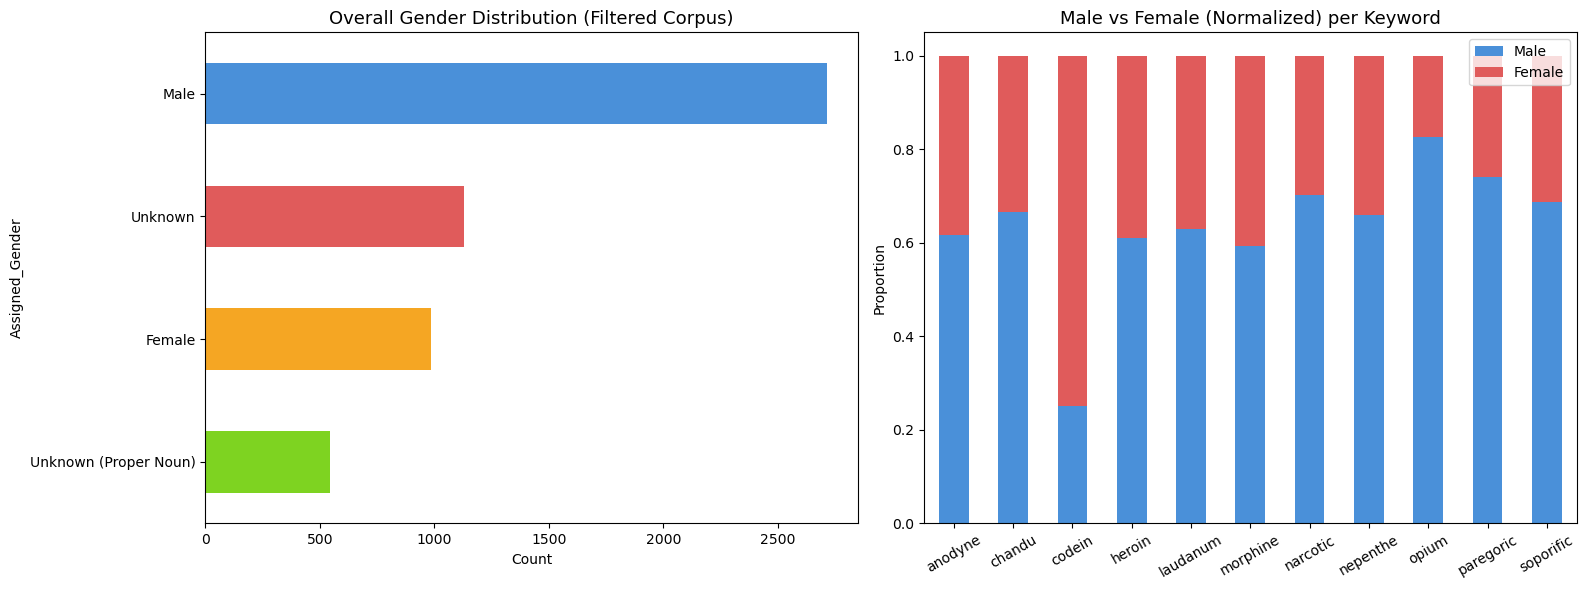

Plots saved.


In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Overall gender distribution
gender_counts = df_all['Assigned_Gender'].value_counts()
colors = ['#4A90D9', '#E05B5B', '#F5A623', '#7ED321', '#9B59B6', '#1ABC9C', '#F39C12']
gender_counts.plot(kind='barh', ax=axes[0], color=colors[:len(gender_counts)])
axes[0].set_title('Overall Gender Distribution (Filtered Corpus)', fontsize=13)
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

# Plot 2: Male vs Female per keyword (stacked bar, normalized)
mf = df_all[df_all['Assigned_Gender'].isin(['Male', 'Female'])]
pivot = mf.groupby(['Keyword', 'Assigned_Gender']).size().unstack(fill_value=0)
pivot = pivot[['Male', 'Female']] # Enforce column order so colors match legend
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)
pivot_norm.plot(kind='bar', stacked=True, ax=axes[1], color=['#4A90D9', '#E05B5B'])
axes[1].set_title('Male vs Female (Normalized) per Keyword', fontsize=13)
axes[1].set_ylabel('Proportion')
axes[1].set_xlabel('')
axes[1].legend(['Male', 'Female'])
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../../data/snippets/gender_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plots saved.")


In [13]:
pd.set_option('display.max_colwidth', None)

In [14]:
df_all[['Snippet', 'Keyword', 'Assigned_Gender']].sample(20)

,Snippet,Keyword,Assigned_Gender
2304,"of living. And he would awake and sniff in the morning air, and say to himself that he was a cur last night, and that he would stay and hold his own, and, in the end, win somehow. The bulldog strain asserted itself, and he was his own again. At night, after a fruitless day, he might become again depressed, but the morning restrung the bow. Sometimes--these were his weaker days--he would abandon all effort, and seek the free public library, and there plunge into books and find, for the passing time, forgetfulness. These were his only draughts of absolute nepenthe , for at night he dreamed of the yesterday or of the morrow, and it marred his rest. The library gave him, for the time, another world, though it had harsh suggestions. He would stop his reading to wonder how Chatterton felt when starving, or if Hood had as miserable a time of it as alleged, or if Goldsmith was jolly when, penniless, he argued his way through Europe, or if even Shakespeare went without a meal. But the library, on the whole, was a solace and a tonic. It rested him, since it made him, for a time, forget.",nepenthe,Unknown (Proper Noun)
2902,"see, then, that I have no arms, and thus cannot help thee?” Since 1848, then, this poet, whom the lovely objects of Nature have always “haunted like a passion,” has not descended from the second story of a Parisian house; this man of hungry intellect has been shut out from all direct observation of life, all contact with society, except such as is derived from visitors to his sick-room. The terrible nervous disease has affected his eyes; the sight of one is utterly gone, and he can only raise the lid of the other by lifting it with his finger. Opium alone is the beneficent genius that stills his pain. We hardly know whether to call it an alleviation or an intensification of the torture that Heine retains his mental vigor, his poetic imagination, and his incisive wit; for if this intellectual activity fills up a blank, it widens the sphere of suffering. His brother described him in 1851 as still, in moments when the hand of pain was not too heavy on him, the same Heinrich Heine, poet and satirist by turns. In such moments he would narrate the strangest things in the gravest manner. But when he came to",opium,Male
5231,"you tell him I was sorry. That will show you.” “Say it!” murmured the man, peremptorily. “Let me hear the words, as she might say them.” She turned upon her side to smile at him. Her voice had grown so faint that it seemed but a disembodied, yearning tenderness that spoke. “In love’s name, then, and hers, _absolvo te_”--And the thread of sound dropped into a silence that was to remain unbroken. The man lay still, clenching his hands and unclenching them. The thrusts of pain had grown very sharp, but he grimly set his teeth. He might ask for morphine ; but if he took it “Arthur” might come and go while he lay in stupor, and the message remain forever undelivered. He looked at the clock on the opposite wall. Perhaps he had still three hours to wait. What should he do? That last dart was keenest of them all. What did people do in torture, people who had made promises that they must stay to keep? Surely there was something. Ah, that was it. Of course. They prayed. Then why not he, as well? His lips moved feverishly. “Christ, thou who suffered for love’s sake, give me--give me",morphine,Male
4819,"charity’s sake, and gave him five rupees, a dinner, and some old clothes. When he had eaten, Dana Da professed gratitude, and asked if there were anything he could do for his host—in the esoteric line. “Is there any one that you love?” said Dana Da. The Englishman loved his wife, but had no desire to drag her name into the conversation. He therefore shook his head. “Is there any one that you hate?” said Dana Da. The Englishman said that there were several men whom he hated deeply. “Very good,” said Dana Da, upon whom the whiskey and the opium were beginning to tell. “Only give

Reasonable enough?

Plot saved as gender_trend_over_time.png


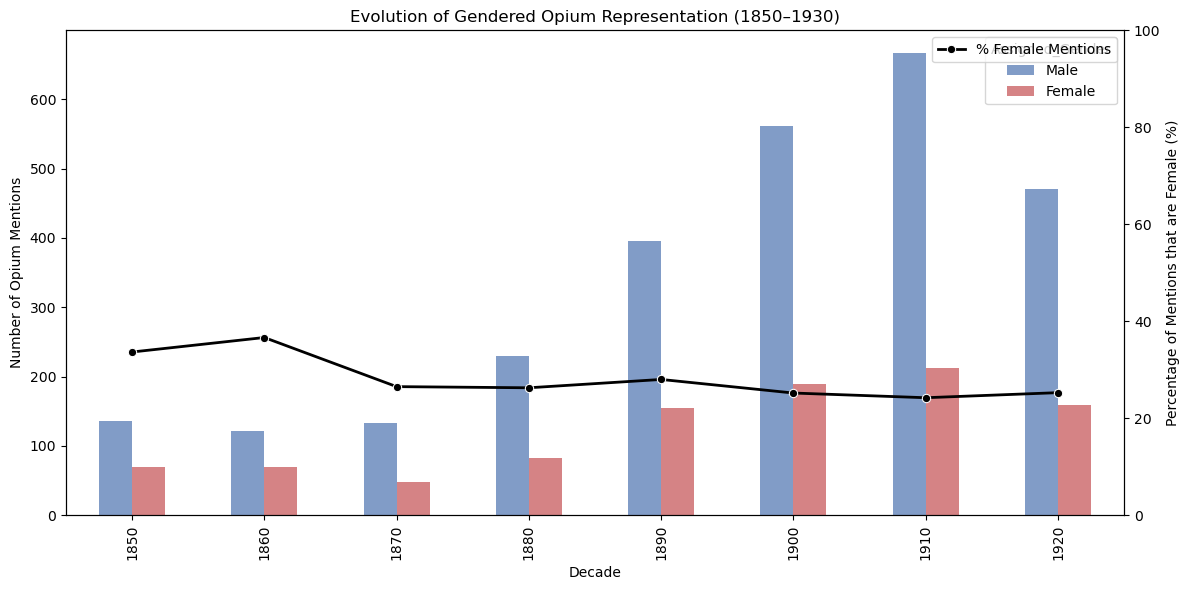

In [15]:
import seaborn as sns

def plot_gender_trends(df):
    # 1. Clean the year and create a Decade column
    # Assuming 'Year' is your column name from the Chronoberg data
    df = df[df['Published Year'].notnull()].copy()
    df['Decade'] = (df['Published Year'] // 10) * 10
    
    # 2. Filter to our primary comparison groups (excluding Unknowns for the trend)
    trend_df = df[df['Assigned_Gender'].isin(['Male', 'Female'])]
    
    # 3. Create a pivot table of counts per decade
    dist = trend_df.groupby(['Decade', 'Assigned_Gender']).size().unstack(fill_value=0)
    
    # 4. Calculate Percentage of Female Mentions (The "Visibility" Metric)
    dist['Total'] = dist['Male'] + dist['Female']
    dist['% Female'] = (dist['Female'] / dist['Total']) * 100

    # 5. Plotting
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Bar chart for raw counts
    dist[['Male', 'Female']].plot(kind='bar', ax=ax1, color=['#4C72B0', '#C44E52'], alpha=0.7)
    ax1.set_ylabel('Number of Opium Mentions')
    ax1.set_xlabel('Decade')
    ax1.set_title('Evolution of Gendered Opium Representation (1850–1930)')

    # Line chart for the percentage (The "Rupture" line)
    ax2 = ax1.twinx()
    sns.lineplot(data=dist, x=range(len(dist)), y='% Female', ax=ax2, color='black', marker='o', linewidth=2, label='% Female Mentions')
    ax2.set_ylabel('Percentage of Mentions that are Female (%)')
    ax2.set_ylim(0, 100)
    
    plt.tight_layout()
    plt.savefig('../../data/snippets/gender_trend_over_time.png')
    print("Plot saved as gender_trend_over_time.png")

# Run the plot
plot_gender_trends(df_all)

The data reveals a consistent 3:1 male-to-female ratio, reflecting the historical dominance of male archetypes in the literary market. The noticeable dip in female visibility between 1860 and 1880 aligns with the 1868 Pharmacy Act, suggesting that increased regulation may have pushed female consumption further into the "invisible" domestic sphere. While the raw volume of mentions exploded during the 1890–1910 "Golden Age" of urban sensationalism, the percentage of female mentions remained stable (~25%). 